In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

print("✔ All libraries loaded successfully")
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Importing plotly failed. Interactive plots will not work.


✔ All libraries loaded successfully


In [2]:
# ── Path to your dataset ──────────────────────────────────────
DATA_PATH  = r'C:\Users\Amey\OneDrive - College of Engineering Pune(An autonomous Institute of Govt. of Maharashtra)\Desktop\Amey\Python\100\Preprocessing\100_Pre_done_Combined.xlsx'   # <-- change this
OUTPUT_DIR = r'C:\Users\Amey\OneDrive - College of Engineering Pune(An autonomous Institute of Govt. of Maharashtra)\Desktop\Amey\Python\100\Predictive_Analysis'    # folder where charts & Excel will be saved

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Season mapping ────────────────────────────────────────────
def get_season(m):
    if m in [12, 1, 2]:       return 'Winter'
    elif m in [3, 4, 5]:      return 'Summer'
    elif m in [6, 7, 8, 9]:   return 'Monsoon'
    else:                      return 'Post-Monsoon'

# ── Evaluation metrics ────────────────────────────────────────
def metrics(actual, predicted, label='Model'):
    actual    = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"  [{label}]  MAE={mae:.1f}  |  RMSE={rmse:.1f}  |  MAPE={mape:.2f}%")
    return {'Model': label, 'MAE': round(mae,1), 'RMSE': round(rmse,1), 'MAPE': round(mape,2)}

print("✔ Config and helpers ready")

✔ Config and helpers ready


In [3]:
# ── Load raw data ─────────────────────────────────────────────
df_raw = pd.read_excel(DATA_PATH)
df_raw['Pstng Date'] = pd.to_datetime(df_raw['Pstng Date'])

# ── Aggregate to monthly level ────────────────────────────────
monthly = (df_raw
    .groupby(['Year', 'Month'])
    .agg(
        Consumption=('Quantity', 'sum'),
        Tavg       =('Tavg',    'mean'),
        Tmax       =('Tmax',    'mean'),
        Tmin       =('Tmin',    'mean'),
        RH         =('RH',      'mean'),
        Delta_T    =('Delta_T', 'mean')
    )
    .reset_index()
)
monthly['Date'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))
monthly = monthly.sort_values('Date').reset_index(drop=True)
monthly['Season'] = monthly['Month'].apply(get_season)

# ── Lag features ──────────────────────────────────────────────
monthly['lag_1']  = monthly['Consumption'].shift(1)
monthly['lag_2']  = monthly['Consumption'].shift(2)
monthly['lag_3']  = monthly['Consumption'].shift(3)
monthly['lag_6']  = monthly['Consumption'].shift(6)
monthly['lag_12'] = monthly['Consumption'].shift(12)

# ── Rolling averages ──────────────────────────────────────────
monthly['roll_3'] = monthly['Consumption'].shift(1).rolling(3).mean()
monthly['roll_6'] = monthly['Consumption'].shift(1).rolling(6).mean()

# ── Cyclical month encoding ───────────────────────────────────
monthly['sin_month'] = np.sin(2 * np.pi * monthly['Month'] / 12)
monthly['cos_month'] = np.cos(2 * np.pi * monthly['Month'] / 12)

# ── Season dummies ────────────────────────────────────────────
season_dummies = pd.get_dummies(monthly['Season'], prefix='season', drop_first=True)
monthly = pd.concat([monthly, season_dummies], axis=1)

print(f"✔ Dataset shape      : {monthly.shape}")
print(f"✔ Date range         : {monthly['Date'].min().strftime('%b %Y')} → {monthly['Date'].max().strftime('%b %Y')}")
print(f"✔ Total months       : {len(monthly)}")
print(f"\n First 5 rows:")
monthly[['Date','Consumption','Tavg','RH','Delta_T','Season','lag_1','lag_12','roll_3']].head()

✔ Dataset shape      : (76, 22)
✔ Date range         : Jan 2020 → Apr 2026
✔ Total months       : 76

 First 5 rows:


,Date,Consumption,Tavg,RH,Delta_T,Season,lag_1,lag_12,roll_3
0,2020-01-01,-78,17.412805,66.535732,12.985610,Winter,NaN,NaN,NaN
1,2020-02-01,-74,20.243140,51.149419,15.637674,Winter,-78.0,NaN,NaN
2,2020-03-01,-56,23.336452,54.755968,14.288226,Summer,-74.0,NaN,NaN
3,2020-04-01,-16,28.129375,43.636875,15.198750,Summer,-56.0,NaN,-69.333333
4,2020-05-01,-14,33.021000,44.450500,13.624500,Summer,-16.0,NaN,-48.666667


In [4]:
# ── Load raw data ─────────────────────────────────────────────
df_raw = pd.read_excel(DATA_PATH)
df_raw['Pstng Date'] = pd.to_datetime(df_raw['Pstng Date'])

# ── Aggregate to monthly level ────────────────────────────────
monthly = (df_raw
    .groupby(['Year', 'Month'])
    .agg(
        Consumption=('Quantity', 'count'),
        Tavg       =('Tavg',    'mean'),
        Tmax       =('Tmax',    'mean'),
        Tmin       =('Tmin',    'mean'),
        RH         =('RH',      'mean'),
        Delta_T    =('Delta_T', 'mean')
    )
    .reset_index()
)
monthly['Date'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))
monthly = monthly.sort_values('Date').reset_index(drop=True)
monthly['Season'] = monthly['Month'].apply(get_season)

# ── Lag features ──────────────────────────────────────────────
monthly['lag_1']  = monthly['Consumption'].shift(1)
monthly['lag_2']  = monthly['Consumption'].shift(2)
monthly['lag_3']  = monthly['Consumption'].shift(3)
monthly['lag_6']  = monthly['Consumption'].shift(6)
monthly['lag_12'] = monthly['Consumption'].shift(12)

# ── Rolling averages ──────────────────────────────────────────
monthly['roll_3'] = monthly['Consumption'].shift(1).rolling(3).mean()
monthly['roll_6'] = monthly['Consumption'].shift(1).rolling(6).mean()

# ── Cyclical month encoding ───────────────────────────────────
monthly['sin_month'] = np.sin(2 * np.pi * monthly['Month'] / 12)
monthly['cos_month'] = np.cos(2 * np.pi * monthly['Month'] / 12)

# ── Season dummies ────────────────────────────────────────────
season_dummies = pd.get_dummies(monthly['Season'], prefix='season', drop_first=True)
monthly = pd.concat([monthly, season_dummies], axis=1)

print(f"✔ Dataset shape      : {monthly.shape}")
print(f"✔ Date range         : {monthly['Date'].min().strftime('%b %Y')} → {monthly['Date'].max().strftime('%b %Y')}")
print(f"✔ Total months       : {len(monthly)}")
print(f"\n First 5 rows:")
monthly[['Date','Consumption','Tavg','RH','Delta_T','Season','lag_1','lag_12','roll_3']].head()

✔ Dataset shape      : (76, 22)
✔ Date range         : Jan 2020 → Apr 2026
✔ Total months       : 76

 First 5 rows:


,Date,Consumption,Tavg,RH,Delta_T,Season,lag_1,lag_12,roll_3
0,2020-01-01,82,17.412805,66.535732,12.985610,Winter,NaN,NaN,NaN
1,2020-02-01,86,20.243140,51.149419,15.637674,Winter,82.0,NaN,NaN
2,2020-03-01,62,23.336452,54.755968,14.288226,Summer,86.0,NaN,NaN
3,2020-04-01,16,28.129375,43.636875,15.198750,Summer,62.0,NaN,76.666667
4,2020-05-01,20,33.021000,44.450500,13.624500,Summer,16.0,NaN,54.666667


In [5]:
# ── Split ─────────────────────────────────────────────────────
TRAIN_END = '2024-12'
VAL_END   = '2026-04'

train = monthly[monthly['Date'] <= TRAIN_END].copy()
val   = monthly[(monthly['Date'] > TRAIN_END) & (monthly['Date'] <= VAL_END)].copy()

print(f"✔ Training set  : {train['Date'].min().strftime('%b %Y')} → {train['Date'].max().strftime('%b %Y')}  ({len(train)} months)")
print(f"✔ Validation    : {val['Date'].min().strftime('%b %Y')}  → {val['Date'].max().strftime('%b %Y')}   ({len(val)} months)")
print(f"✔ Forecast      : May 2026 → Dec 2026  (8 months)\n")

# ── Augmented Dickey-Fuller stationarity test ─────────────────
adf_result = adfuller(train['Consumption'].dropna())
print(f"── Stationarity Check (ADF Test) ──")
print(f"   ADF Statistic  : {adf_result[0]:.4f}")
print(f"   p-value        : {adf_result[1]:.4f}")
print(f"   Result         : {'STATIONARY ✔ (p < 0.05)' if adf_result[1] < 0.05 else 'NON-STATIONARY → differencing will be applied in SARIMAX'}")

✔ Training set  : Jan 2020 → Dec 2024  (60 months)
✔ Validation    : Jan 2025  → Apr 2026   (16 months)
✔ Forecast      : May 2026 → Dec 2026  (8 months)

── Stationarity Check (ADF Test) ──
   ADF Statistic  : 0.3115
   p-value        : 0.9779
   Result         : NON-STATIONARY → differencing will be applied in SARIMAX


In [6]:
# ── Historical monthly averages (2020–2025) ───────────────────
forecast_months = list(range(5, 13))    # May to December

hist_weather = (monthly[monthly['Year'] <= 2025]
                .groupby('Month')[['Tavg','Tmax','Tmin','RH','Delta_T']]
                .mean())

future_weather = pd.DataFrame({
    'Month'  : forecast_months,
    'Year'   : 2026,
    'Date'   : pd.date_range('2026-05-01', periods=8, freq='MS'),
    'Season' : [get_season(m) for m in forecast_months],
    'Tavg'   : [hist_weather.loc[m,'Tavg']    for m in forecast_months],
    'Tmax'   : [hist_weather.loc[m,'Tmax']    for m in forecast_months],
    'Tmin'   : [hist_weather.loc[m,'Tmin']    for m in forecast_months],
    'RH'     : [hist_weather.loc[m,'RH']      for m in forecast_months],
    'Delta_T': [hist_weather.loc[m,'Delta_T'] for m in forecast_months],
})

print("✔ Future weather features (historical averages):\n")
future_weather[['Date','Season','Tavg','RH','Delta_T']].to_string(index=False)

✔ Future weather features (historical averages):



'      Date       Season      Tavg        RH   Delta_T\n2026-05-01       Summer 32.470632 42.298077 13.112347\n2026-06-01      Monsoon 32.954940 51.334901 10.471848\n2026-07-01      Monsoon 29.809840 75.431796  7.030832\n2026-08-01      Monsoon 28.316031 81.283119  6.855200\n2026-09-01      Monsoon 27.338064 82.076197  7.122461\n2026-10-01 Post-Monsoon 25.115599 70.031542 10.749599\n2026-11-01 Post-Monsoon 20.816342 62.586252 12.551494\n2026-12-01       Winter 17.363141 57.883755 13.770891'

                                     SARIMAX Results                                      
Dep. Variable:                        Consumption   No. Observations:                   60
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -764.523
Date:                            Tue, 02 Jun 2026   AIC                           1545.045
Time:                                    11:09:22   BIC                           1557.017
Sample:                                         0   HQIC                          1549.074
                                             - 60                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1           -10.5806         -0        inf      0.000     -10.581     -10.581
x2            -4.6680         -0   

c:\Users\Amey\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


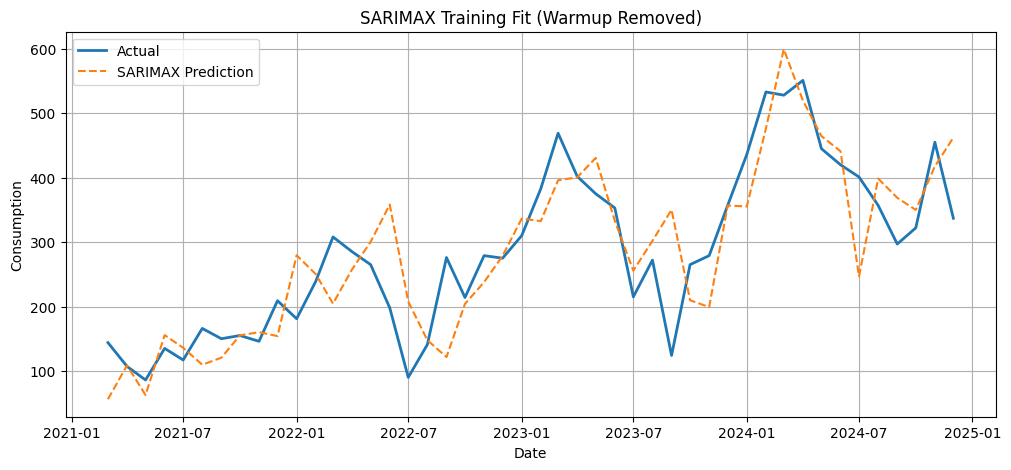


SARIMAX Training MAPE (Warmup Removed):
24.47


In [95]:
# ── SARIMAX: Seasonal ARIMA with Exogenous Regressors ─────────
# ── SARIMAX: Seasonal ARIMA with Exogenous Regressors ─────────

exog_cols = ['Tavg', 'RH', 'Delta_T']

train_exog = train[exog_cols].values
val_exog   = val[exog_cols].values

sarima_model = SARIMAX(
    train['Consumption'],
    exog=train_exog,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

# ============================================================
# TRAINING FIT (FOR OVERFITTING ANALYSIS)
# ============================================================

sarima_train_pred = sarima_fit.fittedvalues

warmup = 14

sarima_train_metrics = metrics(
    train['Consumption'].iloc[warmup:],
    sarima_train_pred.iloc[warmup:],
    'SARIMAX Train'
)

# ============================================================
# VALIDATION FORECAST
# ============================================================

sarima_val_pred = sarima_fit.forecast(
    steps=len(val),
    exog=val_exog
)

sarima_metrics = metrics(
    val['Consumption'],
    sarima_val_pred.values,
    'SARIMAX'
)

# ============================================================
# FUTURE FORECAST (May–Dec 2026)
# ============================================================

future_exog_sarimax = future_weather[exog_cols].values

sarima_future = sarima_fit.forecast(
    steps=len(val) + len(future_weather),
    exog=np.vstack([val_exog, future_exog_sarimax])
)

sarima_forecast_values = sarima_future[-8:]

sarima_preds = (
    np.maximum(
        sarima_forecast_values.values,
        0
    )
    .round()
    .astype(int)
)

print(f"\n✔ SARIMAX forecast (May–Dec 2026): {sarima_preds}")

# ============================================================
# TRAINING FIT PLOT
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    train['Date'].iloc[warmup:],
    train['Consumption'].iloc[warmup:],
    label='Actual',
    linewidth=2
)

plt.plot(
    train['Date'].iloc[warmup:],
    sarima_train_pred.iloc[warmup:],
    '--',
    label='SARIMAX Prediction'
)

plt.title("SARIMAX Training Fit (Warmup Removed)")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.legend()
plt.grid(True)

plt.show()

print("\nSARIMAX Training MAPE (Warmup Removed):")
print(sarima_train_metrics['MAPE'])

11:09:22 - cmdstanpy - INFO - Chain [1] start processing
11:09:22 - cmdstanpy - INFO - Chain [1] done processing


  [Prophet]  MAE=126.5  |  RMSE=160.7  |  MAPE=29.24%

✔ Prophet forecast (May–Dec 2026): [686 618 423 498 398 511 543 597]


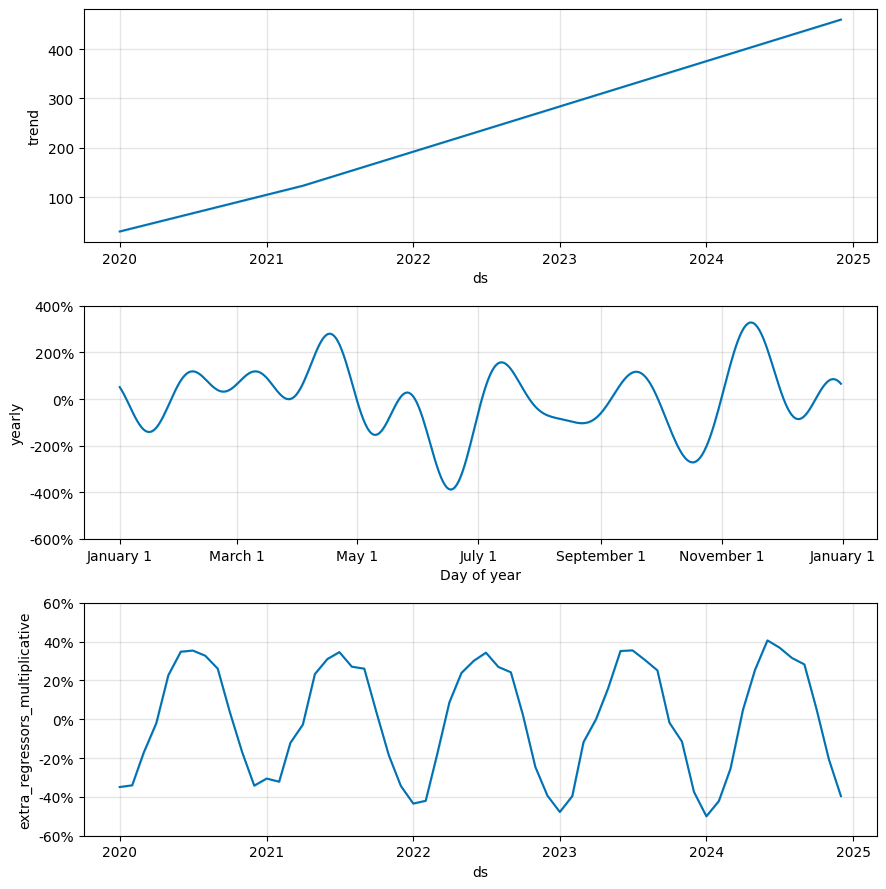

In [96]:
# ── Prophet: Additive Decomposition Model ────────────────────
prophet_train = train[['Date','Consumption','Tavg','RH','Delta_T']].rename(
    columns={'Date':'ds', 'Consumption':'y'})

p_model = Prophet(
    seasonality_mode='multiplicative',   # multiplicative better for growing series
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,         # controls trend flexibility
    seasonality_prior_scale=10           # controls seasonality flexibility
)

# Add weather as extra regressors
p_model.add_regressor('Tavg')
p_model.add_regressor('RH')
p_model.add_regressor('Delta_T')

p_model.fit(prophet_train)

# ── Validation predictions ────────────────────────────────────
prophet_val_future = val[['Date','Tavg','RH','Delta_T']].rename(columns={'Date':'ds'})
prophet_val_pred   = p_model.predict(prophet_val_future)['yhat'].values

# ── Future forecast ───────────────────────────────────────────
prophet_future_df = future_weather[['Date','Tavg','RH','Delta_T']].rename(columns={'Date':'ds'})
prophet_forecast  = p_model.predict(prophet_future_df)
prophet_preds     = np.maximum(prophet_forecast['yhat'].values, 0).round().astype(int)
prophet_lower     = np.maximum(prophet_forecast['yhat_lower'].values, 0).round().astype(int)
prophet_upper     = np.maximum(prophet_forecast['yhat_upper'].values, 0).round().astype(int)

# ── Metrics ───────────────────────────────────────────────────
prophet_metrics = metrics(val['Consumption'], prophet_val_pred, 'Prophet')
print(f"\n✔ Prophet forecast (May–Dec 2026): {prophet_preds}")

# ── Optional: Plot Prophet components ─────────────────────────
fig_comp = p_model.plot_components(p_model.predict(prophet_train.rename(
    columns={'y': 'y_orig', 'ds':'ds'})))
# Uncomment below to see full decomposition
plt.show()

11:09:23 - cmdstanpy - INFO - Chain [1] start processing
11:09:23 - cmdstanpy - INFO - Chain [1] done processing


  [Prophet]  MAE=126.5  |  RMSE=160.7  |  MAPE=29.24%

✔ Prophet forecast (May–Dec 2026): [686 618 423 498 398 511 543 597]


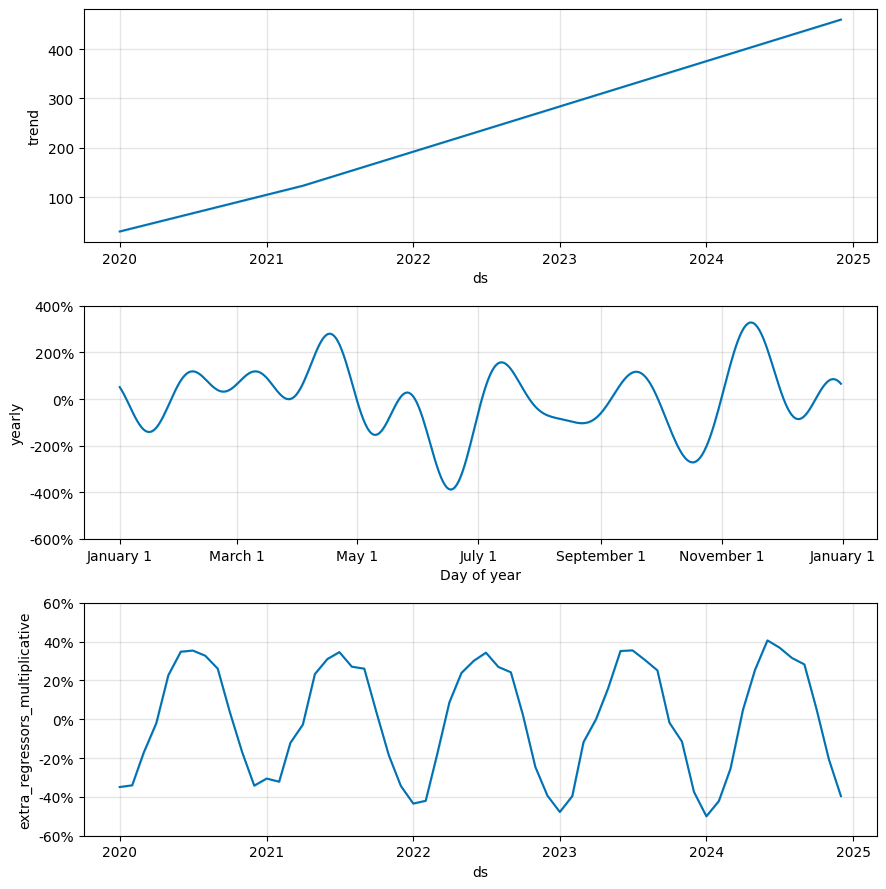

In [97]:
# ── Prophet: Additive Decomposition Model ────────────────────
prophet_train = train[['Date','Consumption','Tavg','RH','Delta_T']].rename(
    columns={'Date':'ds', 'Consumption':'y'})

p_model = Prophet(
    seasonality_mode='multiplicative',   # multiplicative better for growing series
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.1,         # controls trend flexibility
    seasonality_prior_scale=10           # controls seasonality flexibility
)

# Add weather as extra regressors
p_model.add_regressor('Tavg')
p_model.add_regressor('RH')
p_model.add_regressor('Delta_T')

p_model.fit(prophet_train)

# ── Validation predictions ────────────────────────────────────
prophet_val_future = val[['Date','Tavg','RH','Delta_T']].rename(columns={'Date':'ds'})
prophet_val_pred   = p_model.predict(prophet_val_future)['yhat'].values

# ── Future forecast ───────────────────────────────────────────
prophet_future_df = future_weather[['Date','Tavg','RH','Delta_T']].rename(columns={'Date':'ds'})
prophet_forecast  = p_model.predict(prophet_future_df)
prophet_preds     = np.maximum(prophet_forecast['yhat'].values, 0).round().astype(int)
prophet_lower     = np.maximum(prophet_forecast['yhat_lower'].values, 0).round().astype(int)
prophet_upper     = np.maximum(prophet_forecast['yhat_upper'].values, 0).round().astype(int)

# ── Metrics ───────────────────────────────────────────────────
prophet_metrics = metrics(val['Consumption'], prophet_val_pred, 'Prophet')
print(f"\n✔ Prophet forecast (May–Dec 2026): {prophet_preds}")

# ── Optional: Plot Prophet components ─────────────────────────
fig_comp = p_model.plot_components(p_model.predict(prophet_train.rename(
    columns={'y': 'y_orig', 'ds':'ds'})))
# Uncomment below to see full decomposition
plt.show()

In [98]:
# ── Linear Regression ─────────────────────────────────────────

lr_features = [
    'lag_1','lag_2','lag_3','lag_6','lag_12',
    'roll_3','roll_6',
    'Tavg','RH','Delta_T',
    'sin_month','cos_month',
    'Month','Year'
]

# Training data
train_lr = train.dropna(subset=lr_features)

# Validation data
val_lr = val.copy()

full_series = monthly.set_index('Date')['Consumption']

def get_lag(date, lag_months):
    target = date - pd.DateOffset(months=lag_months)
    return full_series.get(target, np.nan)

for _, row in val_lr.iterrows():
    val_lr.at[row.name, 'lag_1']  = get_lag(row['Date'], 1)
    val_lr.at[row.name, 'lag_2']  = get_lag(row['Date'], 2)
    val_lr.at[row.name, 'lag_3']  = get_lag(row['Date'], 3)
    val_lr.at[row.name, 'lag_6']  = get_lag(row['Date'], 6)
    val_lr.at[row.name, 'lag_12'] = get_lag(row['Date'], 12)

    val_lr.at[row.name, 'roll_3'] = np.mean(
        [get_lag(row['Date'], i) for i in range(1,4)]
    )

    val_lr.at[row.name, 'roll_6'] = np.mean(
        [get_lag(row['Date'], i) for i in range(1,7)]
    )

val_lr_filled = val_lr.dropna(subset=lr_features)

# Train model
lr_model = LinearRegression()

lr_model.fit(
    train_lr[lr_features],
    train_lr['Consumption']
)

# Validation prediction
lr_val_pred = lr_model.predict(
    val_lr_filled[lr_features]
)

# Future forecasting
lr_preds = []

known_series = list(monthly['Consumption'].values)

for _, row in future_weather.iterrows():

    month = row['Month']

    feat_row = pd.DataFrame([{
        'lag_1' : known_series[-1],
        'lag_2' : known_series[-2],
        'lag_3' : known_series[-3],
        'lag_6' : known_series[-6],
        'lag_12': known_series[-12],

        'roll_3': np.mean(known_series[-3:]),
        'roll_6': np.mean(known_series[-6:]),

        'Tavg'  : row['Tavg'],
        'RH'    : row['RH'],
        'Delta_T': row['Delta_T'],

        'sin_month': np.sin(2*np.pi*month/12),
        'cos_month': np.cos(2*np.pi*month/12),

        'Month': month,
        'Year' : row['Year']
    }])

    pred = max(0, lr_model.predict(feat_row)[0])

    lr_preds.append(round(pred))

    known_series.append(pred)

# Metrics
lr_metrics = metrics(
    val_lr_filled['Consumption'],
    lr_val_pred,
    'Linear Regression'
)

print(f"\n✔ Linear Regression forecast (May–Dec 2026): {lr_preds}")

  [Linear Regression]  MAE=140.5  |  RMSE=165.9  |  MAPE=34.68%

✔ Linear Regression forecast (May–Dec 2026): [768, 647, 681, 601, 591, 548, 518, 538]


  [XGBoost]  MAE=51.2  |  RMSE=59.7  |  MAPE=12.42%

✔ XGBoost forecast (May–Dec 2026): [469, 413, 455, 384, 379, 420, 429, 387]


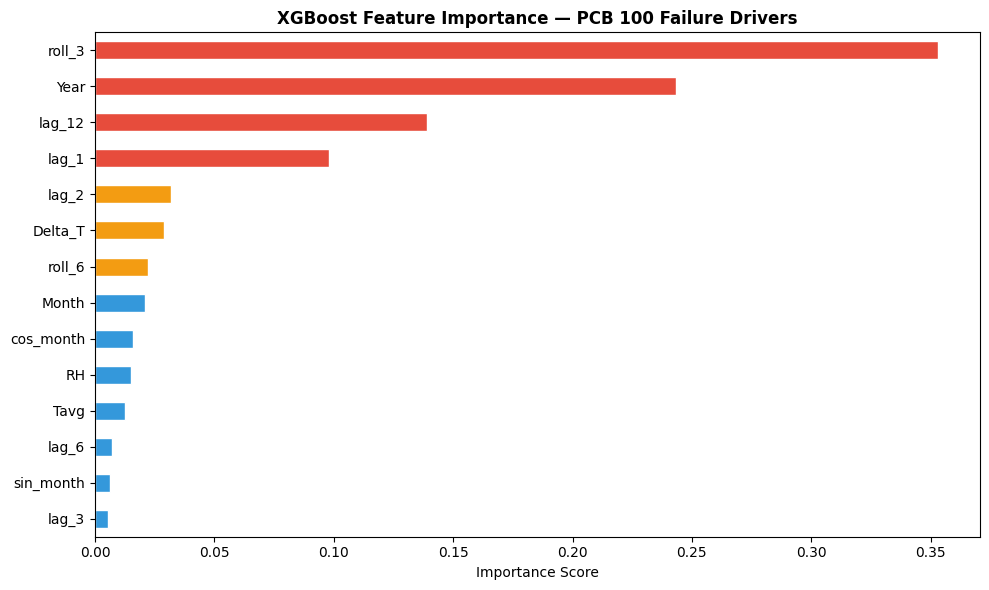

In [99]:
# ── XGBoost: Gradient Boosted Trees ──────────────────────────
xgb_features = ['lag_1','lag_2','lag_3','lag_6','lag_12',
                 'roll_3','roll_6','Tavg','RH','Delta_T',
                 'sin_month','cos_month','Month','Year']

# Drop rows with NaN lag features in training
train_xgb = train.dropna(subset=xgb_features)

# ── Fill validation lag features from known series ────────────
val_xgb       = val.copy()
full_series   = monthly.set_index('Date')['Consumption']

def get_lag(date, lag_months):
    target = date - pd.DateOffset(months=lag_months)
    return full_series.get(target, np.nan)

for _, row in val_xgb.iterrows():
    val_xgb.at[row.name, 'lag_1']  = get_lag(row['Date'], 1)
    val_xgb.at[row.name, 'lag_2']  = get_lag(row['Date'], 2)
    val_xgb.at[row.name, 'lag_3']  = get_lag(row['Date'], 3)
    val_xgb.at[row.name, 'lag_6']  = get_lag(row['Date'], 6)
    val_xgb.at[row.name, 'lag_12'] = get_lag(row['Date'], 12)
    val_xgb.at[row.name, 'roll_3'] = np.mean([get_lag(row['Date'], i) for i in range(1, 4)])
    val_xgb.at[row.name, 'roll_6'] = np.mean([get_lag(row['Date'], i) for i in range(1, 7)])

# ── Train model ───────────────────────────────────────────────
xgb_model = XGBRegressor(
    n_estimators=300,           # number of trees
    max_depth=4,                # tree depth — prevents overfitting
    learning_rate=0.05,         # shrinkage
    subsample=0.8,              # row sampling per tree
    colsample_bytree=0.8,       # feature sampling per tree
    reg_alpha=1.0,              # L1 regularisation
    reg_lambda=2.0,             # L2 regularisation
    random_state=42,
    verbosity=0
)
xgb_model.fit(train_xgb[xgb_features], train_xgb['Consumption'])

# ── Validation predictions ────────────────────────────────────
val_xgb_filled = val_xgb.dropna(subset=xgb_features)
xgb_val_pred   = xgb_model.predict(val_xgb_filled[xgb_features])

# ── Future forecast — rolling (each prediction feeds the next) ─
xgb_preds    = []
known_series = list(monthly['Consumption'].values)

for _, row in future_weather.iterrows():
    month = row['Month']
    feat_row = pd.DataFrame([{
        'lag_1' : known_series[-1],   'lag_2' : known_series[-2],
        'lag_3' : known_series[-3],   'lag_6' : known_series[-6],
        'lag_12': known_series[-12],
        'roll_3': np.mean(known_series[-3:]),
        'roll_6': np.mean(known_series[-6:]),
        'Tavg'  : row['Tavg'],  'RH': row['RH'],  'Delta_T': row['Delta_T'],
        'sin_month': np.sin(2*np.pi*month/12),
        'cos_month': np.cos(2*np.pi*month/12),
        'Month': month, 'Year': row['Year']
    }])
    pred = max(0, xgb_model.predict(feat_row)[0])
    xgb_preds.append(round(pred))
    known_series.append(pred)   # feed back for next iteration

# ── Metrics ───────────────────────────────────────────────────
xgb_metrics = metrics(val_xgb_filled['Consumption'], xgb_val_pred, 'XGBoost')
print(f"\n✔ XGBoost forecast (May–Dec 2026): {xgb_preds}")

# ── Feature Importance Plot ───────────────────────────────────
fi = pd.Series(xgb_model.feature_importances_, index=xgb_features).sort_values()
colors_fi = ['#e74c3c' if x > fi.quantile(0.75) else
             '#f39c12' if x > fi.quantile(0.5) else '#3498db' for x in fi]

fig, ax = plt.subplots(figsize=(10, 6))
fi.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
ax.set_title('XGBoost Feature Importance — PCB 100 Failure Drivers', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [100]:
# ── Weighted Ensemble (inverse-MAPE weights) ──────────────────

all_metrics = [
    sarima_metrics,
    prophet_metrics,
    xgb_metrics,
    lr_metrics
]

metrics_df = pd.DataFrame(all_metrics).set_index('Model')

# Inverse-MAPE weights
weights = 1 / metrics_df['MAPE']
weights = weights / weights.sum()

print("\nEnsemble Weights:")
print(f"  SARIMAX            : {weights['SARIMAX']:.3f} ({weights['SARIMAX']*100:.1f}%)")
print(f"  Prophet            : {weights['Prophet']:.3f} ({weights['Prophet']*100:.1f}%)")
print(f"  XGBoost            : {weights['XGBoost']:.3f} ({weights['XGBoost']*100:.1f}%)")
print(f"  Linear Regression  : {weights['Linear Regression']:.3f} ({weights['Linear Regression']*100:.1f}%)")

# ── Ensemble validation score ─────────────────────────────────

min_len = min(
    len(sarima_val_pred),
    len(prophet_val_pred),
    len(xgb_val_pred),
    len(lr_val_pred)
)

ensemble_val_pred = (
    weights['SARIMAX'] * sarima_val_pred.values[:min_len]
    + weights['Prophet'] * prophet_val_pred[:min_len]
    + weights['XGBoost'] * xgb_val_pred[:min_len]
    + weights['Linear Regression'] * lr_val_pred[:min_len]
)

ens_metrics = metrics(
    val['Consumption'].values[:min_len],
    ensemble_val_pred,
    'Ensemble'
)

all_metrics.append(ens_metrics)

# ── Ensemble forecast ─────────────────────────────────────────

ensemble_preds = (
    weights['SARIMAX'] * np.array(sarima_preds, dtype=float)
    + weights['Prophet'] * np.array(prophet_preds, dtype=float)
    + weights['XGBoost'] * np.array(xgb_preds, dtype=float)
    + weights['Linear Regression'] * np.array(lr_preds, dtype=float)
).round().astype(int)

# ── Confidence intervals ──────────────────────────────────────

recent_std = monthly['Consumption'].tail(24).std()

ensemble_lower = np.maximum(
    ensemble_preds - 1.65 * recent_std,
    0
).round().astype(int)

ensemble_upper = (
    ensemble_preds + 1.65 * recent_std
).round().astype(int)

ensemble_lower = np.minimum(ensemble_lower, prophet_lower)
ensemble_upper = np.maximum(ensemble_upper, prophet_upper)

# ── Print comparison table ────────────────────────────────────

print("\n── FINAL MODEL COMPARISON ──")
print(pd.DataFrame(all_metrics).set_index('Model').to_string())


Ensemble Weights:
  SARIMAX            : 0.364 (36.4%)
  Prophet            : 0.151 (15.1%)
  XGBoost            : 0.356 (35.6%)
  Linear Regression  : 0.128 (12.8%)
  [Ensemble]  MAE=57.3  |  RMSE=74.8  |  MAPE=14.77%

── FINAL MODEL COMPARISON ──
                     MAE   RMSE   MAPE
Model                                 
SARIMAX             49.1   60.5  12.15
Prophet            126.5  160.7  29.24
XGBoost             51.2   59.7  12.42
Linear Regression  140.5  165.9  34.68
Ensemble            57.3   74.8  14.77



TRAIN vs VALIDATION PERFORMANCE
  [SARIMAX Train]  MAE=53.8  |  RMSE=72.9  |  MAPE=24.47%




  [Prophet Train]  MAE=27.7  |  RMSE=35.7  |  MAPE=25.25%

  [XGBoost Train]  MAE=1.0  |  RMSE=1.4  |  MAPE=0.47%

  [Linear Regression Train]  MAE=31.4  |  RMSE=44.3  |  MAPE=15.13%

OVERFITTING ANALYSIS
            Model  Train_MAPE  Validation_MAPE  Difference         Assessment
          SARIMAX       24.47            12.15      -12.32           Good Fit
          Prophet       25.25            29.24        3.99       Underfitting
          XGBoost        0.47            12.42       11.95 Strong Overfitting
Linear Regression       15.13            34.68       19.55 Strong Overfitting


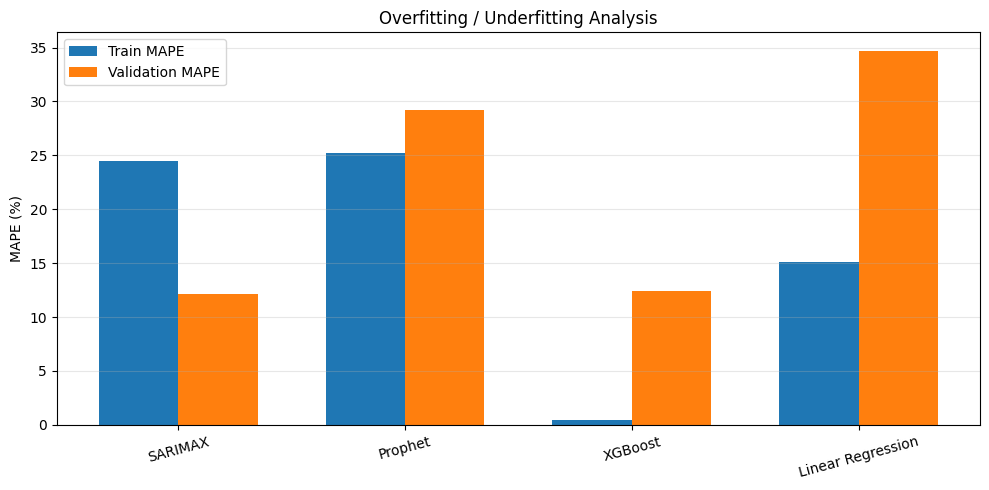

In [101]:
# ============================================================
# OVERFITTING / UNDERFITTING CHECK
# ============================================================

print("\n" + "="*70)
print("TRAIN vs VALIDATION PERFORMANCE")
print("="*70)

# ---------------- SARIMAX ----------------

warmup = 14   # or 12 if you prefer

sarima_train_metrics = metrics(
    train['Consumption'].iloc[warmup:],
    sarima_train_pred.iloc[warmup:],
    'SARIMAX Train'
)

print()
print()

# ---------------- Prophet ----------------

prophet_train_pred = p_model.predict(
    prophet_train[['ds','Tavg','RH','Delta_T']]
)['yhat'].values

prophet_train_metrics = metrics(
    prophet_train['y'],
    prophet_train_pred,
    'Prophet Train'
)

print()

# ---------------- XGBoost ----------------

xgb_train_pred = xgb_model.predict(
    train_xgb[xgb_features]
)

xgb_train_metrics = metrics(
    train_xgb['Consumption'],
    xgb_train_pred,
    'XGBoost Train'
)

print()

# ---------------- Linear Regression ----------------

lr_train_pred = lr_model.predict(
    train_lr[lr_features]
)

lr_train_metrics = metrics(
    train_lr['Consumption'],
    lr_train_pred,
    'Linear Regression Train'
)

# ============================================================
# OVERFITTING ANALYSIS TABLE
# ============================================================

print("\n" + "="*70)
print("OVERFITTING ANALYSIS")
print("="*70)

analysis_df = pd.DataFrame({
    'Model': [
        'SARIMAX',
        'Prophet',
        'XGBoost',
        'Linear Regression'
    ],
    'Train_MAPE': [
        sarima_train_metrics['MAPE'],
        prophet_train_metrics['MAPE'],
        xgb_train_metrics['MAPE'],
        lr_train_metrics['MAPE']
    ],
    'Validation_MAPE': [
        sarima_metrics['MAPE'],
        prophet_metrics['MAPE'],
        xgb_metrics['MAPE'],
        lr_metrics['MAPE']
    ]
})

analysis_df['Difference'] = (
    analysis_df['Validation_MAPE']
    - analysis_df['Train_MAPE']
)

# ============================================================
# CLASSIFICATION
# ============================================================

def classify(train_mape, val_mape):

    diff = val_mape - train_mape

    if train_mape > 25 and val_mape > 25:
        return "Underfitting"

    elif diff < 5:
        return "Good Fit"

    elif diff < 10:
        return "Mild Overfitting"

    else:
        return "Strong Overfitting"

analysis_df['Assessment'] = analysis_df.apply(
    lambda row: classify(
        row['Train_MAPE'],
        row['Validation_MAPE']
    ),
    axis=1
)

print(analysis_df.to_string(index=False))

# ============================================================
# VISUAL COMPARISON
# ============================================================

plt.figure(figsize=(10,5))

x = np.arange(len(analysis_df))
width = 0.35

plt.bar(
    x - width/2,
    analysis_df['Train_MAPE'],
    width,
    label='Train MAPE'
)

plt.bar(
    x + width/2,
    analysis_df['Validation_MAPE'],
    width,
    label='Validation MAPE'
)

plt.xticks(
    x,
    analysis_df['Model'],
    rotation=15
)

plt.ylabel("MAPE (%)")
plt.title("Overfitting / Underfitting Analysis")
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [102]:
print("Train observations :", len(train))
print("Fitted values      :", len(sarima_fit.fittedvalues))

print("\nFirst 15 Actual Values")
print(train['Consumption'].head(15).to_list())

print("\nFirst 15 Fitted Values")
print(pd.Series(sarima_fit.fittedvalues).head(15).to_list())

Train observations : 60
Fitted values      : 60

First 15 Actual Values
[82, 86, 62, 16, 20, 109, 86, 86, 85, 119, 97, 110, 104, 131, 144]

First 15 Fitted Values
[-586.6931689225133, -64.55096387393905, 108.55509030178496, 29.392093263514994, -1.7710128431135672, -30.10992678942955, 30.810738998981606, 73.08897871543468, 95.8968324765492, 175.2325090917284, 184.35509734845596, 159.19115048865694, 451.650473207378, 336.80448586932744, 56.116787608620825]


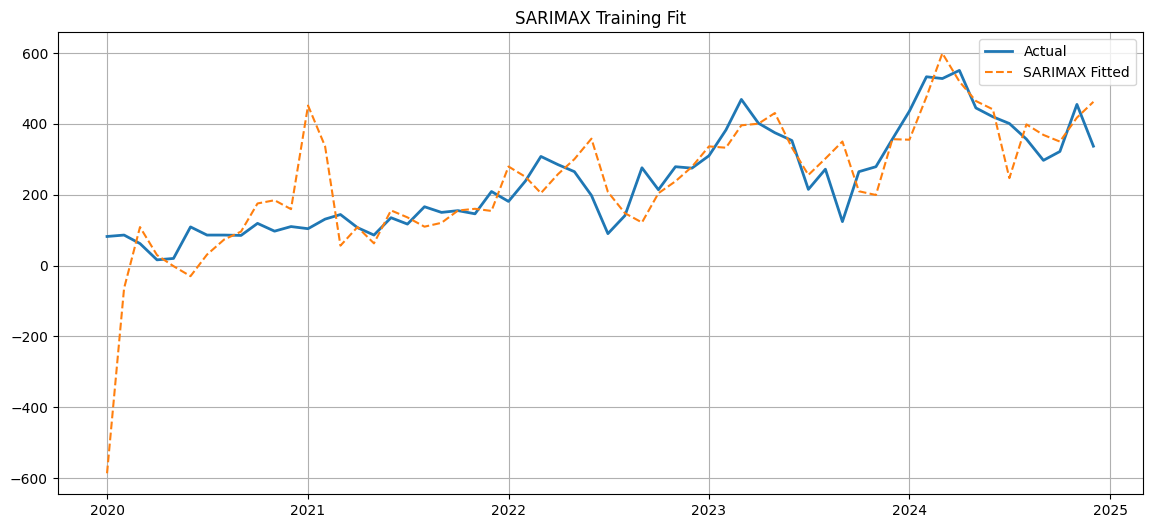

In [103]:
plt.figure(figsize=(14,6))

plt.plot(
    train['Date'],
    train['Consumption'],
    label='Actual',
    linewidth=2
)

plt.plot(
    train['Date'],
    sarima_fit.fittedvalues,
    '--',
    label='SARIMAX Fitted'
)

plt.title("SARIMAX Training Fit")
plt.legend()
plt.grid(True)
plt.show()

In [104]:
# ── Final forecast DataFrame ──────────────────────────────────
forecast_dates = pd.date_range('2026-05-01', periods=8, freq='MS')

forecast_table = pd.DataFrame({
    'Month'      : [d.strftime('%b %Y') for d in forecast_dates],
    'Season'     : future_weather['Season'].values,
    'SARIMAX'    : sarima_preds,
    'Prophet'    : prophet_preds,
    'XGBoost'    : xgb_preds,
    'Ensemble'   : ensemble_preds,
    'Lower_95CI' : ensemble_lower,
    'Upper_95CI' : ensemble_upper,
    'Tavg_°C'    : future_weather['Tavg'].round(1).values,
    'RH_%'       : future_weather['RH'].round(1).values,
})

print("═" * 70)
print("  PCB 100 — MONTHLY FORECAST  |  May 2026 to December 2026")
print("═" * 70)
print(forecast_table.to_string(index=False))
print("─" * 70)
print(f"  TOTAL (Ensemble):  {forecast_table['Ensemble'].sum()}  units")
print("═" * 70)

══════════════════════════════════════════════════════════════════════
  PCB 100 — MONTHLY FORECAST  |  May 2026 to December 2026
══════════════════════════════════════════════════════════════════════
   Month       Season  SARIMAX  Prophet  XGBoost  Ensemble  Lower_95CI  Upper_95CI  Tavg_°C  RH_%
May 2026       Summer      485      686      469       546         392         733     32.5  42.3
Jun 2026      Monsoon      460      618      413       491         337         663     33.0  51.3
Jul 2026      Monsoon      445      423      455       475         321         629     29.8  75.4
Aug 2026      Monsoon      414      498      384       440         286         594     28.3  81.3
Sep 2026      Monsoon      340      398      379       395         241         549     27.3  82.1
Oct 2026 Post-Monsoon      394      511      420       441         287         595     25.1  70.0
Nov 2026 Post-Monsoon      481      543      429       477         323         631     20.8  62.6
Dec 2026       

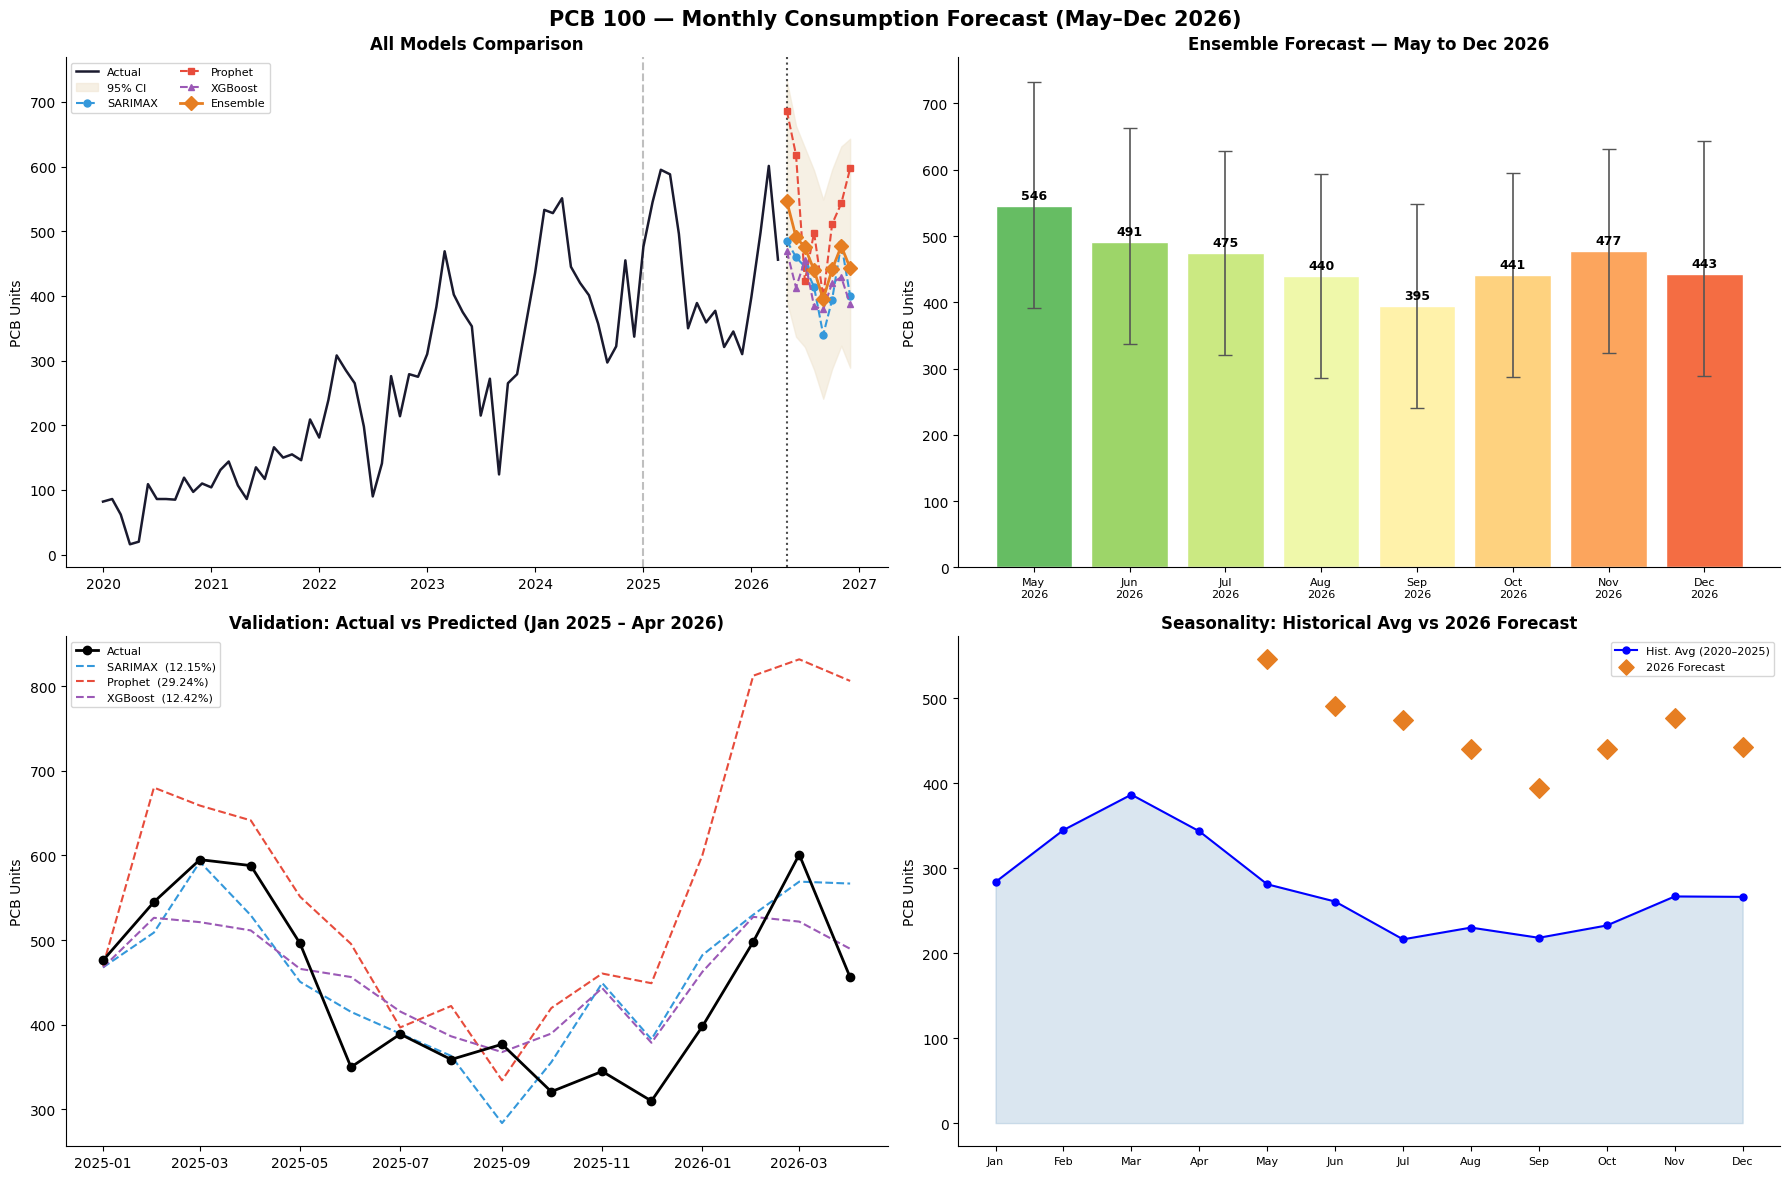

In [105]:
forecast_dates = pd.date_range('2026-05-01', periods=8, freq='MS')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('PCB 100 — Monthly Consumption Forecast (May–Dec 2026)',
             fontsize=15, fontweight='bold')

# ── Plot 1: Full history + all model forecasts ────────────────
ax = axes[0, 0]
ax.plot(monthly['Date'], monthly['Consumption'],
        color='#1a1a2e', lw=1.8, label='Actual', zorder=5)
ax.axvline(pd.to_datetime('2025-01-01'), color='gray', ls='--', alpha=0.5)
ax.axvline(pd.to_datetime('2026-05-01'), color='black', ls=':', alpha=0.7)
ax.fill_between(forecast_dates, ensemble_lower, ensemble_upper,
                color='#f0e6d3', alpha=0.6, label='95% CI')
ax.plot(forecast_dates, sarima_preds,   'o--', color='#3498db', label='SARIMAX',  ms=5)
ax.plot(forecast_dates, prophet_preds,  's--', color='#e74c3c', label='Prophet',  ms=5)
ax.plot(forecast_dates, xgb_preds,     '^--', color='#9b59b6', label='XGBoost',  ms=5)
ax.plot(forecast_dates, ensemble_preds, 'D-',  color='#e67e22', label='Ensemble', ms=7, lw=2)
ax.set_title('All Models Comparison', fontweight='bold')
ax.set_ylabel('PCB Units')
ax.legend(fontsize=8, ncol=2)
ax.spines[['top','right']].set_visible(False)

# ── Plot 2: Ensemble bar chart ────────────────────────────────
ax2 = axes[0, 1]
bar_colors = [plt.cm.RdYlGn_r(x) for x in np.linspace(0.2, 0.8, 8)]
bars = ax2.bar(range(8), ensemble_preds, color=bar_colors, edgecolor='white')
ax2.errorbar(range(8), ensemble_preds,
             yerr=[ensemble_preds - ensemble_lower, ensemble_upper - ensemble_preds],
             fmt='none', color='#555', capsize=5, lw=1.2)
for b, v in zip(bars, ensemble_preds):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 6,
             str(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(range(8))
ax2.set_xticklabels([d.strftime('%b\n%Y') for d in forecast_dates], fontsize=8)
ax2.set_title('Ensemble Forecast — May to Dec 2026', fontweight='bold')
ax2.set_ylabel('PCB Units')
ax2.spines[['top','right']].set_visible(False)

# ── Plot 3: Validation accuracy ───────────────────────────────
ax3 = axes[1, 0]
ax3.plot(val['Date'], val['Consumption'], 'ko-', lw=2, ms=6, label='Actual', zorder=5)
ax3.plot(val['Date'], sarima_val_pred.values,  '--', color='#3498db',
         label=f"SARIMAX  ({sarima_metrics['MAPE']}%)")
ax3.plot(val['Date'], prophet_val_pred,         '--', color='#e74c3c',
         label=f"Prophet  ({prophet_metrics['MAPE']}%)")
ax3.plot(val['Date'][:len(xgb_val_pred)], xgb_val_pred, '--', color='#9b59b6',
         label=f"XGBoost  ({xgb_metrics['MAPE']}%)")
ax3.set_title('Validation: Actual vs Predicted (Jan 2025 – Apr 2026)', fontweight='bold')
ax3.set_ylabel('PCB Units')
ax3.legend(fontsize=8)
ax3.spines[['top','right']].set_visible(False)

# ── Plot 4: Seasonality pattern ───────────────────────────────
ax4 = axes[1, 1]
hist_avg = monthly.groupby('Month')['Consumption'].mean()
ax4.fill_between(range(1,13), hist_avg.values, alpha=0.2, color='steelblue')
ax4.plot(range(1,13), hist_avg.values, 'b-o', ms=5, label='Hist. Avg (2020–2025)')
f_by_month = {future_weather.iloc[i]['Month']: ensemble_preds[i]
              for i in range(len(ensemble_preds))}
for m in range(1, 13):
    if m in f_by_month:
        ax4.scatter(m, f_by_month[m], color='#e67e22', s=100, zorder=5, marker='D')
ax4.set_xticks(range(1,13))
ax4.set_xticklabels(month_names, fontsize=8)
ax4.set_title('Seasonality: Historical Avg vs 2026 Forecast', fontweight='bold')
ax4.set_ylabel('PCB Units')
ax4.scatter([], [], color='#e67e22', marker='D', s=60, label='2026 Forecast')
ax4.legend(fontsize=8)
ax4.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

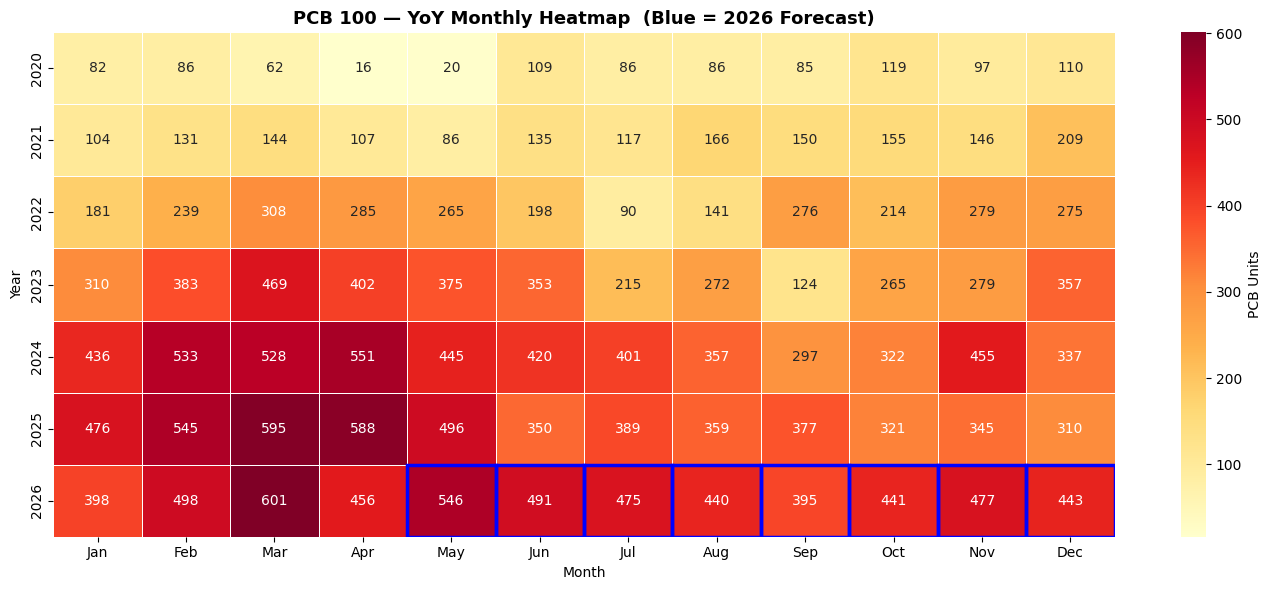

In [106]:
# ── Year-on-Year consumption heatmap ─────────────────────────
pivot = monthly.pivot_table(index='Year', columns='Month',
                            values='Consumption', aggfunc='sum')

# Add 2026 with actuals (Jan–Apr) + forecast (May–Dec)
row_2026 = {}
for m in range(1, 5):
    row_2026[m] = int(monthly[(monthly['Year']==2026) &
                               (monthly['Month']==m)]['Consumption'].values[0])
for i, m in enumerate(range(5, 13)):
    row_2026[m] = int(ensemble_preds[i])
pivot.loc[2026] = row_2026

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'PCB Units'})

# Blue border on forecast cells
for i, m in enumerate(range(5, 13)):
    yr_idx = list(pivot.index).index(2026)
    ax.add_patch(plt.Rectangle((m-1, yr_idx), 1, 1,
                 fill=False, edgecolor='blue', lw=2.5, zorder=5))

ax.set_title('PCB 100 — YoY Monthly Heatmap  (Blue = 2026 Forecast)',
             fontweight='bold', fontsize=13)
ax.set_xticklabels(month_names, rotation=0)
plt.tight_layout()
plt.show()

In [107]:
# Run the full Excel export (4 sheets: Forecast, History, Model Comparison, Region)
# This is the complete openpyxl block — just execute the cell

wb = Workbook()

# ── Shared styles ─────────────────────────────────────────────
DARK_BLUE = '1a1a2e';  MID_BLUE = '16213e';  ACCENT = 'e94560'

def hdr(fg='FFFFFF', bg=DARK_BLUE, bold=True, sz=11, align='center'):
    return {
        'font': Font(bold=bold, color=fg, size=sz, name='Arial'),
        'fill': PatternFill('solid', fgColor=bg),
        'alignment': Alignment(horizontal=align, vertical='center', wrap_text=True),
    }
def cell_style(bold=False, fg='000000', bg=None, align='center', sz=10, wrap=False):
    st = {'font': Font(bold=bold, color=fg, size=sz, name='Arial'),
          'alignment': Alignment(horizontal=align, vertical='center', wrap_text=wrap)}
    if bg: st['fill'] = PatternFill('solid', fgColor=bg)
    return st
def thin_border():
    s = Side(style='thin', color='CCCCCC')
    return Border(left=s, right=s, top=s, bottom=s)
def apply_styles(cell, styles):
    for k, v in styles.items(): setattr(cell, k, v)
    cell.border = thin_border()

season_colors = {'Summer':'FFEAA7','Monsoon':'B2EBF2',
                 'Post-Monsoon':'F8BBD9','Winter':'E1F5FE'}

# ── Sheet 1: Forecast Summary ─────────────────────────────────
ws1 = wb.active;  ws1.title = 'Forecast Summary'
ws1.sheet_view.showGridLines = False
for c, w in zip('ABCDEFGHIJ', [14,13,11,11,11,11,11,11,11,11]):
    ws1.column_dimensions[c].width = w
ws1.merge_cells('A1:J1')
c = ws1['A1']
c.value = 'PCB 100 — Monthly Consumption Forecast  |  May 2026 to December 2026'
apply_styles(c, hdr(sz=14))
ws1.row_dimensions[1].height = 40

headers = ['Month','Season','SARIMAX','Prophet','XGBoost',
           'Ensemble','Lower 95%CI','Upper 95%CI','Tavg (°C)','RH (%)']
for col, h in enumerate(headers, 1):
    c = ws1.cell(row=2, column=col, value=h)
    apply_styles(c, hdr(sz=10, bg=DARK_BLUE if col != 6 else ACCENT))
ws1.row_dimensions[2].height = 26

for i, row in forecast_table.iterrows():
    r = i + 3;  bg = season_colors.get(row['Season'], 'FFFFFF')
    ws1.row_dimensions[r].height = 22
    vals = [row['Month'], row['Season'], row['SARIMAX'], row['Prophet'],
            row['XGBoost'], row['Ensemble'], row['Lower_95CI'],
            row['Upper_95CI'], row['Tavg_°C'], row['RH_%']]
    for col, cv in enumerate(vals, 1):
        c = ws1.cell(row=r, column=col, value=cv)
        if col == 6:   apply_styles(c, cell_style(bold=True, bg='FFF3CD', sz=11))
        elif col > 6:  apply_styles(c, cell_style(fg='636e72', sz=9))
        else:          apply_styles(c, cell_style(bg=bg if col>1 else None))

r_tot = len(forecast_table) + 3
ws1.merge_cells(f'A{r_tot}:B{r_tot}')
c = ws1.cell(row=r_tot, column=1, value='TOTAL (May–Dec 2026)')
apply_styles(c, hdr(sz=10, bg=MID_BLUE))
for col, col_name in enumerate(['SARIMAX','Prophet','XGBoost','Ensemble',
                                  'Lower_95CI','Upper_95CI'], 3):
    c = ws1.cell(row=r_tot, column=col, value=int(forecast_table[col_name].sum()))
    apply_styles(c, hdr(sz=10, bg=MID_BLUE if col != 6 else ACCENT))

# Metrics block
r_m = r_tot + 2
ws1.merge_cells(f'A{r_m}:D{r_m}')
c = ws1.cell(row=r_m, column=1, value='MODEL VALIDATION METRICS  (Jan 2025 – Apr 2026)')
apply_styles(c, hdr(sz=11, bg=MID_BLUE));  ws1.row_dimensions[r_m].height = 26
for col, h in enumerate(['Model','MAE','RMSE','MAPE (%)'], 1):
    c = ws1.cell(row=r_m+1, column=col, value=h)
    apply_styles(c, hdr(sz=10))
for j, (_, mrow) in enumerate(pd.DataFrame(all_metrics).iterrows()):
    r = r_m + 2 + j;  ws1.row_dimensions[r].height = 20
    for col, cv in enumerate([mrow['Model'], mrow['MAE'], mrow['RMSE'], mrow['MAPE']], 1):
        c = ws1.cell(row=r, column=col, value=cv)
        bg = 'E8F8F5' if mrow['Model'] == 'Ensemble' else None
        apply_styles(c, cell_style(bold=(mrow['Model']=='Ensemble'), bg=bg))
ws1.freeze_panes = 'A3'

# ── Sheet 2: Monthly History ──────────────────────────────────
ws2 = wb.create_sheet('Monthly History');  ws2.sheet_view.showGridLines = False
hist_hdr = ['Date','Year','Month','Season','Consumption',
            'Tavg (°C)','Tmax (°C)','Tmin (°C)','RH (%)','Delta_T']
for i, (h, w) in enumerate(zip(hist_hdr,[13,7,7,14,13,10,10,10,8,10]), 1):
    ws2.column_dimensions[get_column_letter(i)].width = w
ws2.merge_cells('A1:J1')
c = ws2['A1'];  c.value = 'PCB 100 — Monthly Historical Data (Jan 2020 – Apr 2026)'
apply_styles(c, hdr(sz=13));  ws2.row_dimensions[1].height = 36
for col, h in enumerate(hist_hdr, 1):
    c = ws2.cell(row=2, column=col, value=h);  apply_styles(c, hdr(sz=10, bg=MID_BLUE))
for i, row in monthly.iterrows():
    r = i + 3;  bg = season_colors.get(get_season(int(row['Month'])), 'FFFFFF')
    vals = [row['Date'].strftime('%b %Y'), int(row['Year']), int(row['Month']),
            get_season(int(row['Month'])), int(row['Consumption']),
            round(row['Tavg'],1), round(row['Tmax'],1), round(row['Tmin'],1),
            round(row['RH'],1), round(row['Delta_T'],1)]
    for col, cv in enumerate(vals, 1):
        c = ws2.cell(row=r, column=col, value=cv)
        apply_styles(c, cell_style(bg=bg if col > 1 else None))
    ws2.row_dimensions[r].height = 18
ws2.freeze_panes = 'A3'

# ── Sheet 3: Model Comparison ─────────────────────────────────
ws3 = wb.create_sheet('Model Comparison');  ws3.sheet_view.showGridLines = False
ws3.merge_cells('A1:G1')
c = ws3['A1'];  c.value = 'Validation: Actual vs Predicted (Jan 2025 – Apr 2026)'
apply_styles(c, hdr(sz=13));  ws3.row_dimensions[1].height = 36
for i, (h, w) in enumerate(zip(['Date','Actual','SARIMAX','Prophet',
                                  'XGBoost','Ensemble','Error %'],
                                 [13,12,10,10,12,10,12]), 1):
    ws3.column_dimensions[get_column_letter(i)].width = w
    c = ws3.cell(row=2, column=i, value=h);  apply_styles(c, hdr(sz=10, bg=MID_BLUE))
for i, date in enumerate(val['Date'].values):
    r = i + 3;  actual = int(val['Consumption'].iloc[i])
    sar = int(round(sarima_val_pred.values[i]))
    pro = int(round(prophet_val_pred[i]))
    xgbv = int(round(xgb_val_pred[i])) if i < len(xgb_val_pred) else '-'
    ens  = int(round(ensemble_val_pred[i])) if i < len(ensemble_val_pred) else '-'
    err  = f"{((ens-actual)/actual*100):+.1f}%" if isinstance(ens, int) else '-'
    err_bg = ('E8F8F5' if isinstance(ens,int) and abs((ens-actual)/actual)<0.1 else
              'FFF3CD' if isinstance(ens,int) and abs((ens-actual)/actual)<0.2 else 'FFEAA7')
    for col, cv in enumerate([pd.Timestamp(date).strftime('%b %Y'),
                               actual, sar, pro, xgbv, ens, err], 1):
        c = ws3.cell(row=r, column=col, value=cv)
        apply_styles(c, cell_style(bg=err_bg if col==7 else None))
    ws3.row_dimensions[r].height = 18
ws3.freeze_panes = 'A3'

# ── Save ──────────────────────────────────────────────────────
xl_path = f'{OUTPUT_DIR}PCB100_Forecast_Report.xlsx'
wb.save(xl_path)
print(f"✔ Excel saved → {xl_path}")

✔ Excel saved → C:\Users\Amey\OneDrive - College of Engineering Pune(An autonomous Institute of Govt. of Maharashtra)\Desktop\Amey\Python\100\Predictive_AnalysisPCB100_Forecast_Report.xlsx
